# Heterogeneous Causal Learning for Effectiveness Optimization

- 기존 uplift 모델은 이질적 처치 효과를 추정할 수 있지만, 비용 대비 이익을 충분히 반영하지 못합니다.

- 마케팅처럼 예산이 제한된 환경에서는, 비용을 고려하면서 효과를 최대화하는 처치 효과 최적화(treatment effect optimization) 접근이 필요합니다.

- 이를 위해 다음 알고리즘들을 활용합니다.
  - Duality R-learner
  - Direct Ranking Model (DRM)
  - Constrained Ranking Models

## Setup

In [1]:
%pip -q install scikit-uplift

Note: you may need to restart the kernel to use updated packages.


In [10]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import r2_score, roc_auc_score

from sklift.datasets import fetch_hillstrom

import matplotlib.pyplot as plt

RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)

import warnings
warnings.filterwarnings("ignore")


### Hillstrom E-mail Test Dataset

Kevin Hillstrom E-mail Test Dataset을 사용합니다.  
이 데이터는 e-mail 마케팅 A/B/n 테스트 로그입니다.

- **Treatment**: ${T}$
  - `Mens E-Mail`, `Womens E-Mail`  $\Rightarrow$  ${T = 1}$ (이메일 발송)
  - `No E-Mail`  $\Rightarrow$  ${T = 0}$ (대조군)

- **Gain outcome**: ${Y^r}$
  - 2주간 지출 금액 `spend`
  - “이메일을 보내면 spend가 얼마나 증가하는가?” 가 관심

- **Cost outcome**: ${Y^c}$
  - 이메일 발송 1회당 비용을 1 단위로 단순화
  - 따라서 $Y^c = T \in \{0,1\}$


In [11]:
dataset = fetch_hillstrom(target_col="spend", return_X_y_t=False)

data = dataset.data.copy()                # X (features, 아직 전처리 전)
y_gain = dataset.target.copy()            # Y^r = spend
treatment_raw = dataset.treatment.copy()  # 'Mens E-Mail', 'Womens E-Mail', 'No E-Mail'

print("data shape:", data.shape)
print("\nspend (target) describe:")
print(y_gain.describe())

print("\nsegment (treatment_raw) 분포:")
print(treatment_raw.value_counts(normalize=True))

data.head()

data shape: (64000, 8)

spend (target) describe:
count    64000.000000
mean         1.050908
std         15.036448
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        499.000000
Name: spend, dtype: float64

segment (treatment_raw) 분포:
segment
Womens E-Mail    0.334172
Mens E-Mail      0.332922
No E-Mail        0.332906
Name: proportion, dtype: float64


,recency,history_segment,history,mens,womens,zip_code,newbie,channel
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web


In [12]:
T = (treatment_raw != "No E-Mail").astype(int)  # 이메일 받았으면 1, 아니면 0

Y_gain = y_gain.astype(float)   # spend (float)
Y_cost = T.astype(float)        # 이메일 발송 비용 (0/1)

print("Treatment 비율 (T=1):", T.mean())
print("\nY_gain (spend) 요약:")
print(pd.Series(Y_gain).describe())

print("\nY_cost 분포:")
print(pd.Series(Y_cost).value_counts(normalize=True).rename("proportion"))


Treatment 비율 (T=1): 0.66709375

Y_gain (spend) 요약:
count    64000.000000
mean         1.050908
std         15.036448
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        499.000000
Name: spend, dtype: float64

Y_cost 분포:
segment
1.0    0.667094
0.0    0.332906
Name: proportion, dtype: float64


### Feature 전처리

Hillstrom의 주요 feature 예시:

- `recency`, `history`, `mens`, `womens`, `newbie` 등: 숫자/0-1 변수
- `history_segment`, `zip_code`, `channel`: 범주형

R-learner / Propensity 모델에 넣기 위해

- 숫자형 컬럼은 그대로 사용하고,
- 범주형 컬럼(`history_segment`, `zip_code`, `channel`)은 one-hot 인코딩으로 변환합니다.


In [13]:
print("원본 feature columns:")
print(data.columns.tolist())

# one-hot 대상 범주형 컬럼
categorical_cols = ["history_segment", "zip_code", "channel"]

# 나머지는 숫자/0-1 컬럼으로 그대로 사용
numeric_cols = [c for c in data.columns if c not in categorical_cols]

print("\nNumeric columns:")
print(numeric_cols)
print("\nCategorical columns (one-hot 대상):")
print(categorical_cols)

# one-hot 인코딩
X_cat = pd.get_dummies(data[categorical_cols], drop_first=True)
X_num = data[numeric_cols].reset_index(drop=True)

X_df = pd.concat([X_num, X_cat], axis=1)

print("\n전처리 후 feature shape:", X_df.shape)
print("전처리된 feature columns:")
print(X_df.columns)

# numpy array로 변환
X = X_df.values.astype(np.float32)


원본 feature columns:
['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel']

Numeric columns:
['recency', 'history', 'mens', 'womens', 'newbie']

Categorical columns (one-hot 대상):
['history_segment', 'zip_code', 'channel']

전처리 후 feature shape: (64000, 15)
전처리된 feature columns:
Index(['recency', 'history', 'mens', 'womens', 'newbie',
       'history_segment_2) $100 - $200', 'history_segment_3) $200 - $350',
       'history_segment_4) $350 - $500', 'history_segment_5) $500 - $750',
       'history_segment_6) $750 - $1,000', 'history_segment_7) $1,000 +',
       'zip_code_Surburban', 'zip_code_Urban', 'channel_Phone', 'channel_Web'],
      dtype='object')


데이터 세트는 각각 60%, 20%, 20%의 비율로 학습, 검증 및 테스트 세트의 3부분으로 나뉩니다.

In [14]:
# Train / Validation / Test 분할
X_train_val, X_test, T_train_val, T_test, Yg_train_val, Yg_test, Yc_train_val, Yc_test = train_test_split(
    X, T, Y_gain, Y_cost,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=T,
)

X_train, X_val, T_train, T_val, Yg_train, Yg_val, Yc_train, Yc_val = train_test_split(
    X_train_val, T_train_val, Yg_train_val, Yc_train_val,
    test_size=0.25,  # 0.25 * 0.8 = 0.2
    random_state=RANDOM_STATE,
    stratify=T_train_val,
)

print("Train shape:", X_train.shape)
print("Val   shape:", X_val.shape)
print("Test  shape:", X_test.shape)

print("\nTreatment 비율 (Train/Val/Test):")
print("Train:", T_train.mean())
print("Val  :", T_val.mean())
print("Test :", T_test.mean())


Train shape: (38400, 15)
Val   shape: (12800, 15)
Test  shape: (12800, 15)

Treatment 비율 (Train/Val/Test):
Train: 0.6670833333333334
Val  : 0.667109375
Test : 0.667109375


## Duality R-learner

Duality R-learner는 다음 두 단계를 결합한 방식입니다.

1. R-learner로 Gain/Cost CATE 추정
   - $\tau_r(x)$: gain uplift (예: spend uplift)
   - $\tau_c(x)$: cost uplift (예: 이메일 발송 비용 증가량)

2. 예산 제약(budget constraint)을 듀얼 형태로 최적화
   - 라그랑지 승수 $\lambda$ 를 학습하여 최적 정책을 찾습니다.

우리가 풀고 싶은 문제는 다음과 같습니다.

- 예산 $B$ 하에서

  $$
  \max_{z_i \in \{0,1\}} \sum_i \tau_r(x^{(i)}) z_i
  \quad \text{s.t.} \quad
  \sum_i \tau_c(x^{(i)}) z_i \le B
  $$
  
- $z_i = 1$ 이면 고객 $i$ 에게 이메일 발송, $z_i = 0$ 이면 미발송

Duality R-learner 핵심 단계:

1. Nuisance models: $m_r(x)$, $e(x)$ 학습  
2. Gain / Cost R-learner: $\tau_r(x)$, $\tau_c(x)$ 추정  
3. Duality: $\lambda$ 를 gradient ascent 로 최적화  
4. 정책 생성: $s(x) = \tau_r(x) - \lambda^* \tau_c(x)$
5. Cost Curve / AUCC 로 정책 성능 평가  

### 1. Nuisance Models: $m_r(x)$ 와 $e(x)$

R-learner는 아래 식을 기반으로 합니다.

$$
Y - m^*(X)
= (T - e^*(X))\,\tau^*(X) + \epsilon
$$

여기서  
- $m^*(X) = \mathbb{E}[Y \mid X]$: outcome 평균  
- $e^*(X) = \mathbb{P}(T=1 \mid X)$: propensity score  

Gain outcome에 대한 nuisance 모델은 다음과 같이 구성합니다.

- $m_r(x)$: Ridge 회귀  
- $e(x)$: Logistic 회귀  

Cost outcome은 $Y^c = T$ 이므로
$m_c(x) = e(x)$

In [15]:
# Gain outcome 평균 모델 m_r(x): Ridge 회귀
m_r = Ridge(alpha=1.0, random_state=RANDOM_STATE)
m_r.fit(X_train, Yg_train)

Yg_pred_train = m_r.predict(X_train)
Yg_pred_val   = m_r.predict(X_val)

r2_train = r2_score(Yg_train, Yg_pred_train)
r2_val   = r2_score(Yg_val,   Yg_pred_val)

print("== m_r(x) 성능 (R^2: spend 회귀) ==")
print("Train R^2:", r2_train)
print("Val   R^2:", r2_val)

print("\n예측값 분포 (Val):")
print(pd.Series(Yg_pred_val).describe())


== m_r(x) 성능 (R^2: spend 회귀) ==
Train R^2: 0.0011321804124860835
Val   R^2: 0.0006200906912602333

예측값 분포 (Val):
count    12800.000000
mean         0.998539
std          0.499257
min         -4.757108
25%          0.690851
50%          0.961950
75%          1.234435
max          4.417754
dtype: float64


In [16]:
# Propensity model e(x) = P(T=1 | X): Logistic 회귀
propensity = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",
    max_iter=1000,
    n_jobs=-1,
)

propensity.fit(X_train, T_train)

e_train = propensity.predict_proba(X_train)[:, 1]
e_val   = propensity.predict_proba(X_val)[:, 1]
e_test  = propensity.predict_proba(X_test)[:, 1]

auc_train_e = roc_auc_score(T_train, e_train)
auc_val_e   = roc_auc_score(T_val,   e_val)

print("== e(x) 성능 (AUC: treatment 모델) ==")
print("Train AUC:", auc_train_e)
print("Val   AUC:", auc_val_e)

print("\nPropensity e(x) range:")
print("Train:", e_train.min(), "→", e_train.max())
print("Val  :", e_val.min(),   "→", e_val.max())


== e(x) 성능 (AUC: treatment 모델) ==
Train AUC: 0.5117265124259399
Val   AUC: 0.49799591470904553

Propensity e(x) range:
Train: 0.633101626124968 → 0.8026040280233658
Val  : 0.6331449838328645 → 0.8183494704982611


여기서 얻은 ${e(x)}$ 는 이후에

- Gain R-learner에서 ${T - e(x)}$ 항을 만들 때,
- Cost R-learner에서 ${m_c(x)}$ 로도 재사용합니다.  

### 2. Gain R-learner: $\tau_r(x)$

Gain outcome $Y^r$ 에 대해 R-learner 구조는 다음과 같습니다.

$$
Y^r - m_r(X)
= (T - e(X))\,\tau_r(X) + \epsilon
$$

선형 모델 $\tau_r(x) = w_r^\top x$ 를 사용하면 학습 절차는 다음과 같습니다.

1. 잔차 계산  

   $$
   r^Y = Y^r - \hat m_r(X), \quad r^T = T - \hat e(X)
   $$

2. 행별 스케일링  

   $$
   Z = X \odot r^T
   $$

3. 회귀  

   $$
   r^Y \approx Z w_r
   $$

4. 최종 CATE  

   $$
   \hat\tau_r(x) = w_r^\top x
   $$

In [19]:
def fit_r_learner_linear(
    X_tr, X_val,
    T_tr, T_val,
    Y_tr, Y_val,
    m_tr, m_val,
    e_tr, e_val,
    alpha=1.0,
    name="R-learner",
):
    """
    선형 τ(x) = w^T x 를 R-learner 방식으로 학습.
    - X_tr, X_val: feature 행렬
    - T_tr, T_val: treatment (0/1)
    - Y_tr, Y_val: outcome
    - m_tr, m_val: m(x) = E[Y|X] 예측값
    - e_tr, e_val: e(x) = P(T=1|X) 예측값
    """
    X_tr = np.asarray(X_tr)
    X_val = np.asarray(X_val)
    T_tr = np.asarray(T_tr).astype(float)
    T_val = np.asarray(T_val).astype(float)
    Y_tr = np.asarray(Y_tr).astype(float)
    Y_val = np.asarray(Y_val).astype(float)
    m_tr = np.asarray(m_tr).astype(float)
    m_val = np.asarray(m_val).astype(float)
    e_tr = np.asarray(e_tr).astype(float)
    e_val = np.asarray(e_val).astype(float)

    # residuals
    rY_tr = Y_tr - m_tr
    rT_tr = T_tr - e_tr

    # Z = X * rT (각 행을 rT로 스케일링)
    Z_tr = X_tr * rT_tr.reshape(-1, 1)

    # 회귀: rY ~ Z
    tau_model = Ridge(alpha=alpha, fit_intercept=False, random_state=RANDOM_STATE)
    tau_model.fit(Z_tr, rY_tr)

    # τ_hat(x) = w^T x
    tau_tr = tau_model.predict(X_tr)
    tau_val = tau_model.predict(X_val)

    print(f"== {name} 요약 ==")
    print("Train τ_hat summary:")
    print(pd.Series(tau_tr).describe())
    print("\nVal τ_hat summary:")
    print(pd.Series(tau_val).describe())

    return tau_model, tau_tr, tau_val


In [20]:
# m_r(x) 예측값
m_r_train = m_r.predict(X_train)
m_r_val   = m_r.predict(X_val)

tau_r_model, tau_r_train, tau_r_val = fit_r_learner_linear(
    X_tr=X_train,
    X_val=X_val,
    T_tr=T_train,
    T_val=T_val,
    Y_tr=Yg_train,
    Y_val=Yg_val,
    m_tr=m_r_train,
    m_val=m_r_val,
    e_tr=e_train,
    e_val=e_val,
    alpha=1.0,
    name="Gain R-learner τ_r(x)",
)


== Gain R-learner τ_r(x) 요약 ==
Train τ_hat summary:
count    38400.000000
mean         0.562616
std          0.454530
min         -2.669276
25%          0.265676
50%          0.528041
75%          0.837171
max          1.976344
dtype: float64

Val τ_hat summary:
count    12800.000000
mean         0.567048
std          0.453703
min         -3.313805
25%          0.272715
50%          0.530470
75%          0.836859
max          1.944813
dtype: float64


### 3. Cost R-learner: $\tau_c(x)$

Cost outcome은 $Y^c = T$ 이므로  
nuisance model은 이미

$$m_c(x) = e(x)$$

입니다.

Cost R-learner 식은

$$
Y^c - m_c(X)
= (T - e(X))\,\tau_c(X)
$$

Gain과 동일한 R-learner 구조로 $\tau_c(x)$ 를 학습합니다.

In [21]:
# Cost outcome 평균 m_c(x)는 e(x)를 그대로 사용
m_c_train = e_train
m_c_val   = e_val

tau_c_model, tau_c_train, tau_c_val = fit_r_learner_linear(
    X_tr=X_train,
    X_val=X_val,
    T_tr=T_train,
    T_val=T_val,
    Y_tr=Yc_train,
    Y_val=Yc_val,
    m_tr=m_c_train,
    m_val=m_c_val,
    e_tr=e_train,
    e_val=e_val,
    alpha=1.0,
    name="Cost R-learner τ_c(x)",
)


== Cost R-learner τ_c(x) 요약 ==
Train τ_hat summary:
count    38400.000000
mean         0.974710
std          0.156975
min          0.429515
25%          0.894193
50%          0.978889
75%          1.046973
max          2.098633
dtype: float64

Val τ_hat summary:
count    12800.000000
mean         0.974875
std          0.157403
min          0.424263
25%          0.894096
50%          0.979144
75%          1.046372
max          2.265868
dtype: float64


In [22]:
# Test set CATE 예측
tau_r_test = tau_r_model.predict(X_test)
tau_c_test = tau_c_model.predict(X_test)

print("== τ_r(x) 요약 ==")
print("[Train]")
print(pd.Series(tau_r_train).describe())
print("\n[Val]")
print(pd.Series(tau_r_val).describe())
print("\n[Test]")
print(pd.Series(tau_r_test).describe())

print("\n== τ_c(x) 요약 ==")
print("[Train]")
print(pd.Series(tau_c_train).describe())
print("\n[Val]")
print(pd.Series(tau_c_val).describe())
print("\n[Test]")
print(pd.Series(tau_c_test).describe())


== τ_r(x) 요약 ==
[Train]
count    38400.000000
mean         0.562616
std          0.454530
min         -2.669276
25%          0.265676
50%          0.528041
75%          0.837171
max          1.976344
dtype: float64

[Val]
count    12800.000000
mean         0.567048
std          0.453703
min         -3.313805
25%          0.272715
50%          0.530470
75%          0.836859
max          1.944813
dtype: float64

[Test]
count    12800.000000
mean         0.568442
std          0.450854
min         -2.486865
25%          0.268170
50%          0.534959
75%          0.841292
max          1.970332
dtype: float64

== τ_c(x) 요약 ==
[Train]
count    38400.000000
mean         0.974710
std          0.156975
min          0.429515
25%          0.894193
50%          0.978889
75%          1.046973
max          2.098633
dtype: float64

[Val]
count    12800.000000
mean         0.974875
std          0.157403
min          0.424263
25%          0.894096
50%          0.979144
75%          1.046372
max        

### 4. Duality: 예산 제약 하에서 라그랑지안 기반 $\lambda$ 최적화

우리가 풀고자 하는 문제는 다음과 같습니다.

$$
\begin{aligned}
\max_{z_i \in \{0,1\}} &\quad \sum_i \tau_r(x^{(i)}) z_i \\
\text{s.t.} &\quad \sum_i \tau_c(x^{(i)}) z_i \le B.
\end{aligned}
$$

여기서 $z_i = 1$ 은 고객 $i$를 타겟팅하는 경우이며, $B$는 전체 예산입니다.  
이 제약을 다루기 위해 라그랑지 승수 $\lambda \ge 0$ 를 도입하면 라그랑지안은

$$
L(z,\lambda)
= -\sum_i \tau_r(x^{(i)}) z_i
+ \lambda\left(\sum_i \tau_c(x^{(i)}) z_i - B\right)
$$

으로 표현됩니다.

고정된 $\lambda$ 아래에서 고객 $i$의 효율성 점수는 다음과 같습니다.

$$
s_i(\lambda) = \tau_r(x^{(i)}) - \lambda\, \tau_c(x^{(i)}).
$$

점수가 양수이면 타겟팅하는 것이 유리하므로  
$s_i(\lambda) \ge 0$ 이면 $z_i = 1$, 음수이면 $z_i = 0$ 을 선택합니다.  
즉, $\lambda$가 주어지면 단순히 $s_i(\lambda)$가 양수인 고객만 선택하면 됩니다.

듀얼 목적함수의 기울기는

$$
\frac{\partial g}{\partial \lambda}
\approx \sum_i z_i \tau_c(x^{(i)}) - B
$$

으로 근사할 수 있고, 이에 따른 gradient ascent 업데이트는

$$
\lambda \leftarrow \bigl[\lambda + \eta(\text{cost\_used} - B)\bigr]_+
$$

로 진행됩니다. 여기서 $[\cdot]_+$ 는 $\lambda$가 음수가 되지 않도록 하는 projection입니다.

예산을 초과하면 $(\text{cost\_used} > B)$ $\lambda$는 증가하여 비용 효과를 더 강하게 억제하고,  
예산보다 적게 사용하면 $\lambda$는 감소하여 더 많은 고객이 선택될 수 있도록 조정됩니다.

Train 데이터에서 양의 Cost CATE 합을 기반으로 예산 $B$를 설정하고,  
위 규칙을 반복 적용하여 최종 $\lambda^*$와 정책을 학습합니다.

In [23]:
def duality_learn_lambda(
    tau_r,
    tau_c,
    budget_fraction=0.3,
    lr=1e-5,
    n_iter=200,
    verbose_every=20,
):
    """
    τ_r, τ_c 가 주어졌을 때 Duality gradient ascent로 λ 학습.
    - budget_fraction: 전체 양의 cost effect 합 중 몇 %를 예산으로 둘지
    """
    tau_r = np.asarray(tau_r).astype(float)
    tau_c = np.asarray(tau_c).astype(float)

    # 양의 cost effect만 예산 계산에 사용
    tau_c_pos = np.clip(tau_c, a_min=0.0, a_max=None)
    total_pos_cost = tau_c_pos.sum()
    B = budget_fraction * total_pos_cost

    lam = 0.0

    for it in range(n_iter + 1):
        # effectiveness score
        s = tau_r - lam * tau_c

        # z_i: 선택 여부 (s_i >= 0 이면 선택)
        z = (s >= 0).astype(float)

        cost_used = (tau_c_pos * z).sum()
        gain_used = (np.clip(tau_r, 0.0, None) * z).sum()

        # ∂g/∂λ ≈ cost_used - B
        grad = cost_used - B

        # gradient ascent (λ >= 0 유지)
        lam = max(0.0, lam + lr * grad)

        if it % verbose_every == 0:
            sel_ratio = z.mean()
            print(
                f"[iter {it:03d}] λ={lam:.6f}, "
                f"cost_used={cost_used:.4f}, gain_used={gain_used:.4f}, "
                f"grad={grad:.4f}, selected={sel_ratio:.3f}"
            )

    print("\n최종 λ*:", lam)
    print("총 양의 cost effect 합:", total_pos_cost)
    print(f"예산 B (fraction={budget_fraction}):", B)
    return lam, B


In [39]:
lambda_star, B = duality_learn_lambda(
    tau_r=tau_r_train,
    tau_c=tau_c_train,
    budget_fraction=0.3,
    lr=1e-5,
    n_iter=200,
    verbose_every=20,
)

[iter 000] λ=0.228487, cost_used=34077.3618, gain_used=22363.6067, grad=22848.7019, selected=0.907
[iter 020] λ=0.784009, cost_used=11251.8179, gain_used=12501.7237, grad=23.1579, selected=0.298
[iter 040] λ=0.784586, cost_used=11228.2803, gain_used=12483.2661, grad=-0.3797, selected=0.297
[iter 060] λ=0.784587, cost_used=11228.2803, gain_used=12483.2661, grad=-0.3797, selected=0.297
[iter 080] λ=0.784587, cost_used=11228.2803, gain_used=12483.2661, grad=-0.3797, selected=0.297
[iter 100] λ=0.784587, cost_used=11228.2803, gain_used=12483.2661, grad=-0.3797, selected=0.297
[iter 120] λ=0.784588, cost_used=11228.2803, gain_used=12483.2661, grad=-0.3797, selected=0.297
[iter 140] λ=0.784588, cost_used=11229.1281, gain_used=12483.9314, grad=0.4682, selected=0.297
[iter 160] λ=0.784588, cost_used=11229.1281, gain_used=12483.9314, grad=0.4682, selected=0.297
[iter 180] λ=0.784589, cost_used=11229.1281, gain_used=12483.9314, grad=0.4682, selected=0.297
[iter 200] λ=0.784589, cost_used=11229.1

In [25]:
def selection_summary(tau_r, tau_c, lam, name=""):
    tau_r = np.asarray(tau_r).astype(float)
    tau_c = np.asarray(tau_c).astype(float)

    s = tau_r - lam * tau_c
    z = (s >= 0).astype(float)

    gain_pos = np.clip(tau_r, 0.0, None)
    cost_pos = np.clip(tau_c, 0.0, None)

    gain_used = (gain_pos * z).sum()
    cost_used = (cost_pos * z).sum()
    sel_ratio = z.mean()

    ratio = gain_used / cost_used if cost_used > 0 else np.nan

    print(f"\n== Selection summary ({name}) ==")
    print(f"λ = {lam:.6f}")
    print(f"선택 비율: {sel_ratio:.3f}  ({z.sum():.0f} / {len(z)})")
    print(f"총 gain (∑ τ_r^+ z): {gain_used:.4f}")
    print(f"총 cost (∑ τ_c^+ z): {cost_used:.4f}")
    print(f"gain / cost 비율: {ratio:.4f}")

    return {
        "lambda": lam,
        "selected_ratio": sel_ratio,
        "gain_used": gain_used,
        "cost_used": cost_used,
        "gain_per_cost": ratio,
    }


In [26]:
_ = selection_summary(tau_r_train, tau_c_train, lambda_star, name="Train")
_ = selection_summary(tau_r_val,   tau_c_val,   lambda_star, name="Val")
_ = selection_summary(tau_r_test,  tau_c_test,  lambda_star, name="Test")



== Selection summary (Train) ==
λ = 0.784589
선택 비율: 0.297  (11420 / 38400)
총 gain (∑ τ_r^+ z): 12483.2661
총 cost (∑ τ_c^+ z): 11228.2803
gain / cost 비율: 1.1118

== Selection summary (Val) ==
λ = 0.784589
선택 비율: 0.293  (3753 / 12800)
총 gain (∑ τ_r^+ z): 4124.4445
총 cost (∑ τ_c^+ z): 3685.4466
gain / cost 비율: 1.1191

== Selection summary (Test) ==
λ = 0.784589
선택 비율: 0.302  (3862 / 12800)
총 gain (∑ τ_r^+ z): 4210.7541
총 cost (∑ τ_c^+ z): 3794.4139
gain / cost 비율: 1.1097


### 5. Cost Curve & AUCC

Cost Curve 와 그 면적(AUCC, Area Under Cost Curve)로 비용 대비 uplift 모델을 평가합니다.

Test 셋에서:

1. Duality 점수 ${s(x) = \tau_r(x) - \lambda^* \tau_c(x)}$ 기준으로 내림차순 정렬
2. 정렬된 순서대로
   - ${\tau_r^+(x) = \max(\tau_r(x), 0)}$
   - ${\tau_c^+(x) = \max(\tau_c(x), 0)}$
   의 누적합 계산
3. 누적 cost/gain 을 각각 최종값으로 나누어 ${[0,1]}$ 범위로 정규화
4. $(0,0)$ 에서 $(1,1)$ 까지 이어지는 곡선을 Cost Curve 로 사용
5. 수치 적분으로 AUCC 계산:
   $$
   \text{AUCC} = \int_0^1 \text{gain}(x)\,dx
   $$

비교를 위해 랜덤 ranking 의 Cost Curve 와 AUCC 도 함께 계산합니다.

- AUCC ${\approx 0.5}$: 랜덤에 가까운 정책
- AUCC ${>} 0.5$: 효율적인 고객부터 잘 고르는 정책


In [27]:
# Duality R-learner 기반 effectiveness score (Test set)
s_test = tau_r_test - lambda_star * tau_c_test

# score 기준 내림차순 정렬
order = np.argsort(-s_test)
tau_r_sorted = np.clip(tau_r_test[order], 0.0, None)  # gain은 양수 부분만
tau_c_sorted = np.clip(tau_c_test[order], 0.0, None)  # cost도 양수 부분만

# 누적 cost / gain
cum_cost = np.cumsum(tau_c_sorted)
cum_gain = np.cumsum(tau_r_sorted)

# 0 지점 포함
cum_cost = np.insert(cum_cost, 0, 0.0)
cum_gain = np.insert(cum_gain, 0, 0.0)

# 정규화
max_cost = cum_cost[-1]
max_gain = cum_gain[-1]

x = cum_cost / max_cost
y = cum_gain / max_gain

# AUCC 계산
aucc = np.trapz(y, x)

print("== Test set Cost Curve (τ 기반) ==")
print("max_cost:", max_cost)
print("max_gain:", max_gain)
print("Normalized AUCC:", aucc)


== Test set Cost Curve (τ 기반) ==
max_cost: 12481.778185597159
max_gain: 7511.766716461641
Normalized AUCC: 0.6946670819574676


Random ranking AUCC: 0.5006872435398204


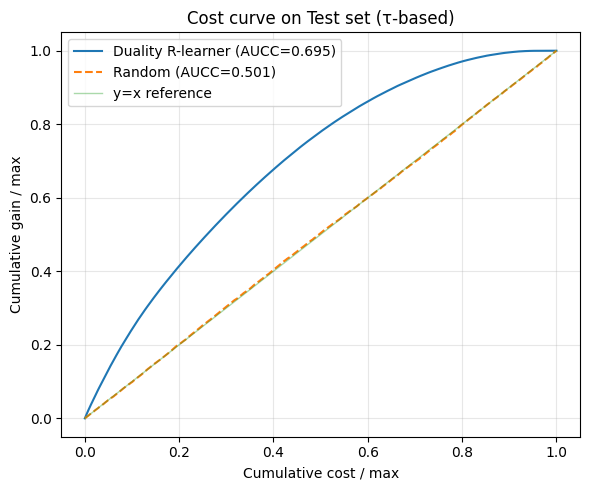

In [28]:
# 랜덤 베이스라인 Cost Curve
rng = np.random.default_rng(RANDOM_STATE)
perm = rng.permutation(len(tau_r_test))

tau_r_rand = np.clip(tau_r_test[perm], 0.0, None)
tau_c_rand = np.clip(tau_c_test[perm], 0.0, None)

cum_cost_rand = np.cumsum(tau_c_rand)
cum_gain_rand = np.cumsum(tau_r_rand)

cum_cost_rand = np.insert(cum_cost_rand, 0, 0.0)
cum_gain_rand = np.insert(cum_gain_rand, 0, 0.0)

x_rand = cum_cost_rand / cum_cost_rand[-1]
y_rand = cum_gain_rand / cum_gain_rand[-1]

aucc_rand = np.trapz(y_rand, x_rand)
print("Random ranking AUCC:", aucc_rand)

# 플롯
plt.figure(figsize=(6, 5))
plt.plot(x,      y,      label=f"Duality R-learner (AUCC={aucc:.3f})")
plt.plot(x_rand, y_rand, linestyle="--", label=f"Random (AUCC={aucc_rand:.3f})")
plt.plot([0, 1], [0, 1], alpha=0.4, linewidth=1, label="y=x reference")

plt.xlabel("Cumulative cost / max")
plt.ylabel("Cumulative gain / max")
plt.title("Cost curve on Test set (τ-based)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
